# NYC Taxi Trips — Hourly and Daily Demand Pattern Analysis

The notebook studies when taxi demand is highest, how demand changes across the week, and how trip duration behaves throughout the day. The analysis also checks the effect of duration outliers before drawing operational conclusions.

### Scope
- Parse `pickup_datetime` and extract hour, weekday, and month.
- Filter unrealistic trip durations using the required 1–120 minute range.
- Compare hourly, daily, and monthly demand.
- Measure average trip duration by hour.
- Add an hour × weekday demand heatmap and vendor comparison.
- Validate each required output and export reusable summary tables.


## Data loading

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# use the desktop file locally and the uploaded copy in this environment
desktop_path = Path(r"C:\Users\anarrasulzada\Desktop\NYC.csv")
data_path = desktop_path if desktop_path.exists() else Path("/mnt/data/NYC.csv")

project_dir = Path.cwd()
visuals_dir = project_dir / "visuals"
outputs_dir = project_dir / "outputs"
visuals_dir.mkdir(exist_ok=True)
outputs_dir.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)

df = pd.read_csv(data_path)
source_shape = df.shape
print(f"dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())

dataset shape: 1,458,644 rows × 11 columns


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


## Data quality and datetime preparation

In [ ]:
# parse datetime once before creating time-based features
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"], errors="coerce")

quality_check = pd.DataFrame({
    "missing_values": df.isna().sum(),
    "dtype": df.dtypes.astype(str)
})

print(f"duplicate trip ids: {df['id'].duplicated().sum():,}")
print(f"total missing values: {df.isna().sum().sum():,}")
display(quality_check)

duplicate trip ids: 0
total missing values: 0


,missing_values,dtype
id,0,object
vendor_id,0,int64
pickup_datetime,0,datetime64[ns]
dropoff_datetime,0,object
passenger_count,0,int64
pickup_longitude,0,float64
pickup_latitude,0,float64
dropoff_longitude,0,float64
dropoff_latitude,0,float64
store_and_fwd_flag,0,object


The dataset contains no missing values and no duplicated trip IDs. `pickup_datetime` is converted before any time extraction, which avoids repeated parsing later in the workflow.

## Trip duration cleaning and outlier impact

In [ ]:
# seconds to minutes 
df["trip_duration_min"] = df["trip_duration"] / 60

# keeping only trips from 1 to 120 minutes, including both boundaries
valid_duration = df["trip_duration_min"].between(1, 120)
analysis_df = df.loc[valid_duration].copy()

outlier_impact = pd.DataFrame({
    "metric": [
        "raw rows", "filtered rows", "removed rows", "under 1 minute",
        "over 120 minutes", "over 24 hours", "raw mean (min)",
        "filtered mean (min)", "raw median (min)", "filtered median (min)"
    ],
    "value": [
        len(df), len(analysis_df), (~valid_duration).sum(),
        (df["trip_duration_min"] < 1).sum(),
        (df["trip_duration_min"] > 120).sum(),
        (df["trip_duration_min"] > 24 * 60).sum(),
        df["trip_duration_min"].mean(), analysis_df["trip_duration_min"].mean(),
        df["trip_duration_min"].median(), analysis_df["trip_duration_min"].median()
    ]
})

display(outlier_impact)
print(f"share removed: {(~valid_duration).mean() * 100:.2f}%")

,metric,value
0,raw rows,1.458644e+06
1,filtered rows,1.447796e+06
2,removed rows,1.084800e+04
3,under 1 minute,8.595000e+03
4,over 120 minutes,2.253000e+03
5,over 24 hours,4.000000e+00
6,raw mean (min),1.599154e+01
7,filtered mean (min),1.401459e+01
8,raw median (min),1.103333e+01
9,filtered median (min),1.108333e+01


share removed: 0.74%


Filtering removes a small fraction of records, but it materially reduces the mean trip duration because the raw data contains extreme values. The median changes very little, illustrating why it is more resistant to outliers.

In [ ]:
# extract reusable calendar fields from pickup time
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]

analysis_df["hour"] = analysis_df["pickup_datetime"].dt.hour
analysis_df["weekday_num"] = analysis_df["pickup_datetime"].dt.dayofweek
analysis_df["weekday"] = pd.Categorical(
    analysis_df["pickup_datetime"].dt.day_name(),
    categories=weekday_order,
    ordered=True
)
analysis_df["month_num"] = analysis_df["pickup_datetime"].dt.month
analysis_df["month"] = analysis_df["pickup_datetime"].dt.strftime("%b")
analysis_df["date"] = analysis_df["pickup_datetime"].dt.normalize()
analysis_df["day_type"] = np.where(analysis_df["weekday_num"] >= 5, "Weekend", "Weekday")

analysis_df[["pickup_datetime", "hour", "weekday", "month", "trip_duration_min"]].head()

,pickup_datetime,hour,weekday,month,trip_duration_min
0,2016-03-14 17:24:55,17,Monday,Mar,7.583333
1,2016-06-12 00:43:35,0,Sunday,Jun,11.050000
2,2016-01-19 11:35:24,11,Tuesday,Jan,35.400000
3,2016-04-06 19:32:31,19,Wednesday,Apr,7.150000
4,2016-03-26 13:30:55,13,Saturday,Mar,7.250000


## Hourly demand and peak windows

In [ ]:
# aggregating trip volume and average duration for every hour
hourly_summary = (
    analysis_df.groupby("hour")
    .agg(trips=("id", "size"), avg_duration_min=("trip_duration_min", "mean"))
    .reset_index()
)
hourly_summary["demand_share_pct"] = hourly_summary["trips"] / len(analysis_df) * 100

peak_row = hourly_summary.loc[hourly_summary["trips"].idxmax()]
offpeak_row = hourly_summary.loc[hourly_summary["trips"].idxmin()]

print(f"peak hour: {int(peak_row['hour']):02d}:00–{(int(peak_row['hour']) + 1) % 24:02d}:00 | {int(peak_row['trips']):,} trips")
print(f"off-peak hour: {int(offpeak_row['hour']):02d}:00–{(int(offpeak_row['hour']) + 1) % 24:02d}:00 | {int(offpeak_row['trips']):,} trips")
display(hourly_summary.round(2))

peak hour: 18:00–19:00 | 90,022 trips
off-peak hour: 05:00–06:00 | 14,767 trips


,hour,trips,avg_duration_min,demand_share_pct
0,0,52775,13.10,3.65
1,1,38221,12.41,2.64
2,2,27661,11.79,1.91
3,3,20637,11.81,1.43
4,4,15524,12.38,1.07
5,5,14767,12.01,1.02
6,6,32933,11.27,2.27
7,7,55213,12.70,3.81
8,8,66662,13.96,4.60
9,9,67253,14.12,4.65


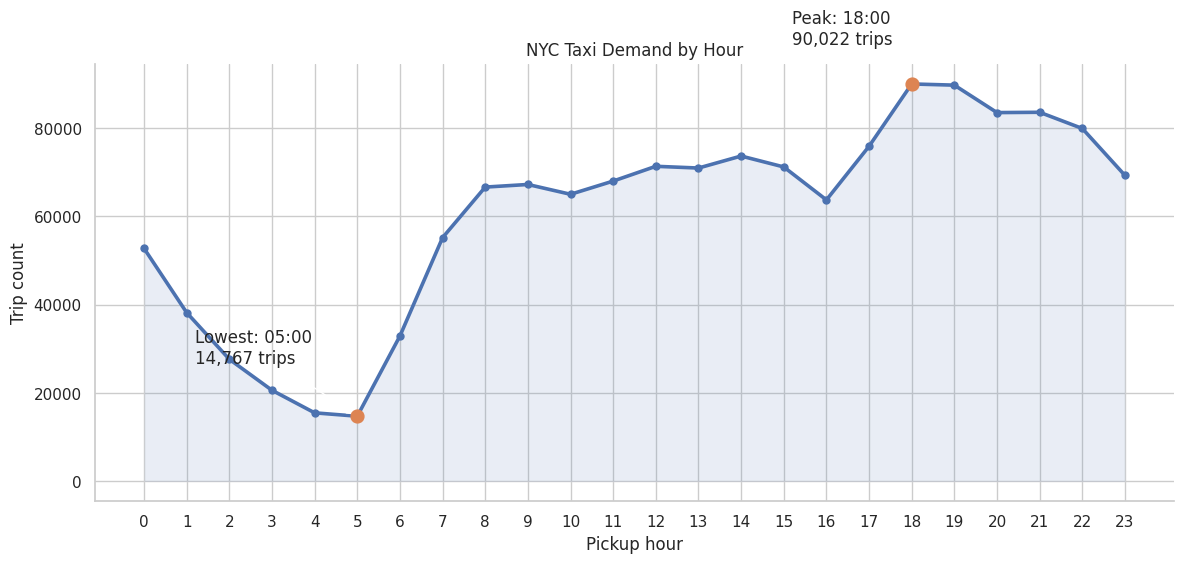

In [ ]:
# visualizing the full demand curve and annotate both extremes
fig, ax = plt.subplots(figsize=(12, 5.8))
ax.plot(hourly_summary["hour"], hourly_summary["trips"], linewidth=2.6, marker="o", markersize=5)
ax.fill_between(hourly_summary["hour"], hourly_summary["trips"], alpha=0.12)
ax.scatter([peak_row["hour"], offpeak_row["hour"]], [peak_row["trips"], offpeak_row["trips"]], s=85, zorder=4)
ax.annotate(
    f"Peak: {int(peak_row['hour']):02d}:00\n{int(peak_row['trips']):,} trips",
    xy=(peak_row["hour"], peak_row["trips"]), xytext=(15.2, peak_row["trips"] + 9000),
    arrowprops={"arrowstyle": "->"}
)
ax.annotate(
    f"Lowest: {int(offpeak_row['hour']):02d}:00\n{int(offpeak_row['trips']):,} trips",
    xy=(offpeak_row["hour"], offpeak_row["trips"]), xytext=(1.2, offpeak_row["trips"] + 12000),
    arrowprops={"arrowstyle": "->"}
)
ax.set(title="NYC Taxi Demand by Hour", xlabel="Pickup hour", ylabel="Trip count")
ax.set_xticks(range(24))
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(visuals_dir / "01_hourly_demand.png", dpi=220, bbox_inches="tight")
plt.show()

## Weekday pattern and weekday vs weekend demand

In [ ]:
# preserve calendar order instead of alphabetical sorting
weekday_summary = (
    analysis_df.groupby("weekday", observed=True)
    .size()
    .rename("trips")
    .reset_index()
)
weekday_summary["share_pct"] = weekday_summary["trips"] / len(analysis_df) * 100

# compare typical calendar days so five weekdays are not unfairly compared with two weekend days
daily_demand = analysis_df.groupby(["date", "day_type"]).size().rename("trips").reset_index()
day_type_summary = (
    daily_demand.groupby("day_type")["trips"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(1)
)

display(weekday_summary)
display(day_type_summary)

,weekday,trips,share_pct
0,Monday,186051,12.850636
1,Tuesday,201318,13.905136
2,Wednesday,208751,14.418537
3,Thursday,216947,14.984639
4,Friday,221870,15.324673
5,Saturday,219190,15.139564
6,Sunday,193669,13.376816


,count,mean,median,min,max
day_type,,,,,
Weekday,130,7961.1,8010.5,5523,9204
Weekend,52,7939.6,8085.0,1627,9714


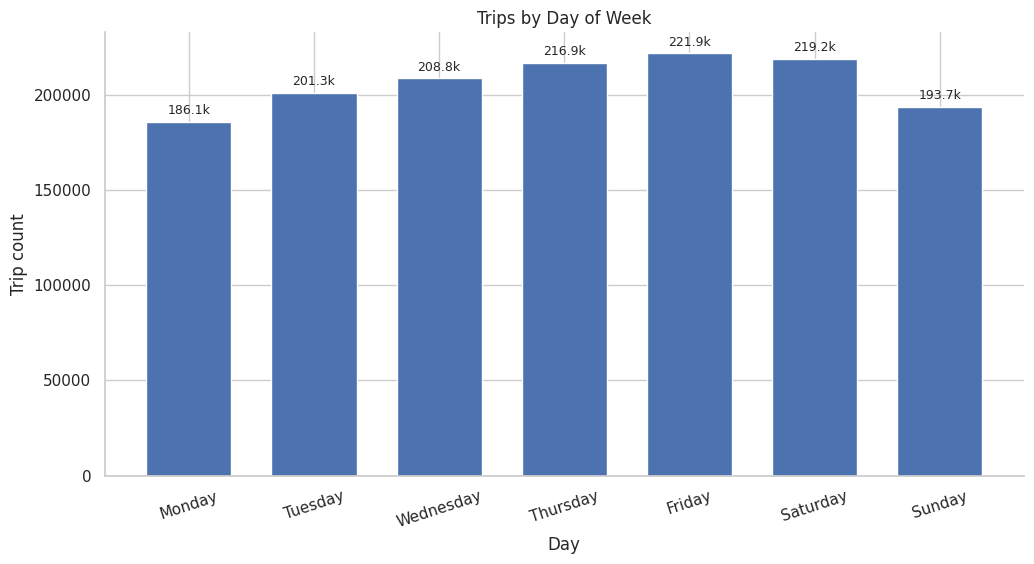

In [ ]:
# used direct labels to keep the weekday comparison readable without a legend
fig, ax = plt.subplots(figsize=(10.5, 5.8))
bars = ax.bar(weekday_summary["weekday"].astype(str), weekday_summary["trips"], width=0.68)
for bar, value in zip(bars, weekday_summary["trips"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 2500, f"{value/1000:.1f}k", ha="center", va="bottom", fontsize=9)
ax.set(title="Trips by Day of Week", xlabel="Day", ylabel="Trip count")
ax.tick_params(axis="x", rotation=18)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(visuals_dir / "02_weekday_demand.png", dpi=220, bbox_inches="tight")
plt.show()

Total weekday volume is naturally larger because there are five weekdays. For fleet planning, the normalized **average trips per calendar day** is the fairer comparison; it shows that a typical weekday and weekend day are much closer than raw totals suggest.

## Trip duration distribution

In [ ]:
# cleaned duration distribution before plotting it
clean_duration_stats = analysis_df["trip_duration_min"].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]).to_frame("trip_duration_min")
display(clean_duration_stats.round(2))

,trip_duration_min
count,1447796.00
mean,14.01
std,10.89
min,1.00
25%,6.68
50%,11.08
75%,17.93
95%,34.80
99%,55.20
max,119.85


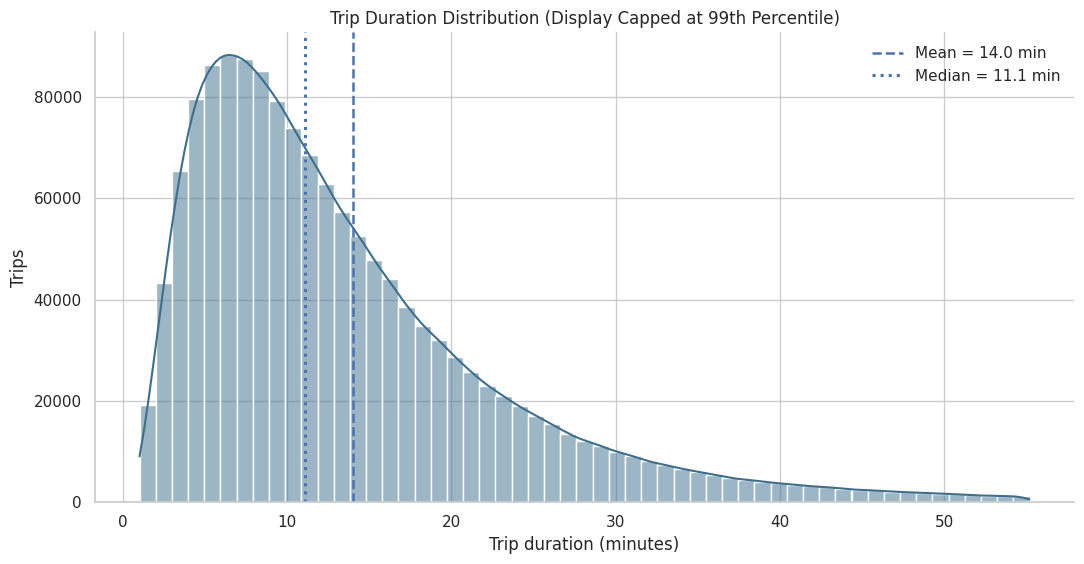

In [ ]:
# limit of the display range to the 99th percentile while retaining all rows in calculations
p99 = analysis_df["trip_duration_min"].quantile(0.99)
mean_duration = analysis_df["trip_duration_min"].mean()
median_duration = analysis_df["trip_duration_min"].median()

fig, ax = plt.subplots(figsize=(11, 5.8))
sns.histplot(
    data=analysis_df.loc[analysis_df["trip_duration_min"] <= p99],
    x="trip_duration_min", bins=55, kde=True, color="#3B6F8F", ax=ax
)
ax.axvline(mean_duration, linestyle="--", linewidth=1.8, label=f"Mean = {mean_duration:.1f} min")
ax.axvline(median_duration, linestyle=":", linewidth=2.2, label=f"Median = {median_duration:.1f} min")
ax.set(title="Trip Duration Distribution (Display Capped at 99th Percentile)", xlabel="Trip duration (minutes)", ylabel="Trips")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(visuals_dir / "03_trip_duration_distribution.png", dpi=220, bbox_inches="tight")
plt.show()

## Average trip duration by hour

In [ ]:
# duration by pickup hour to separate demand volume from congestion exposure
hourly_duration = (
    analysis_df.groupby("hour")["trip_duration_min"]
    .mean()
    .rename("avg_duration_min")
    .reset_index()
)

longest_hour = hourly_duration.loc[hourly_duration["avg_duration_min"].idxmax()]
shortest_hour = hourly_duration.loc[hourly_duration["avg_duration_min"].idxmin()]
print(f"highest average duration: {int(longest_hour['hour']):02d}:00 | {longest_hour['avg_duration_min']:.2f} min")
print(f"lowest average duration: {int(shortest_hour['hour']):02d}:00 | {shortest_hour['avg_duration_min']:.2f} min")
display(hourly_duration.round(2))

highest average duration: 15:00 | 16.16 min
lowest average duration: 06:00 | 11.27 min


,hour,avg_duration_min
0,0,13.10
1,1,12.41
2,2,11.79
3,3,11.81
4,4,12.38
5,5,12.01
6,6,11.27
7,7,12.70
8,8,13.96
9,9,14.12


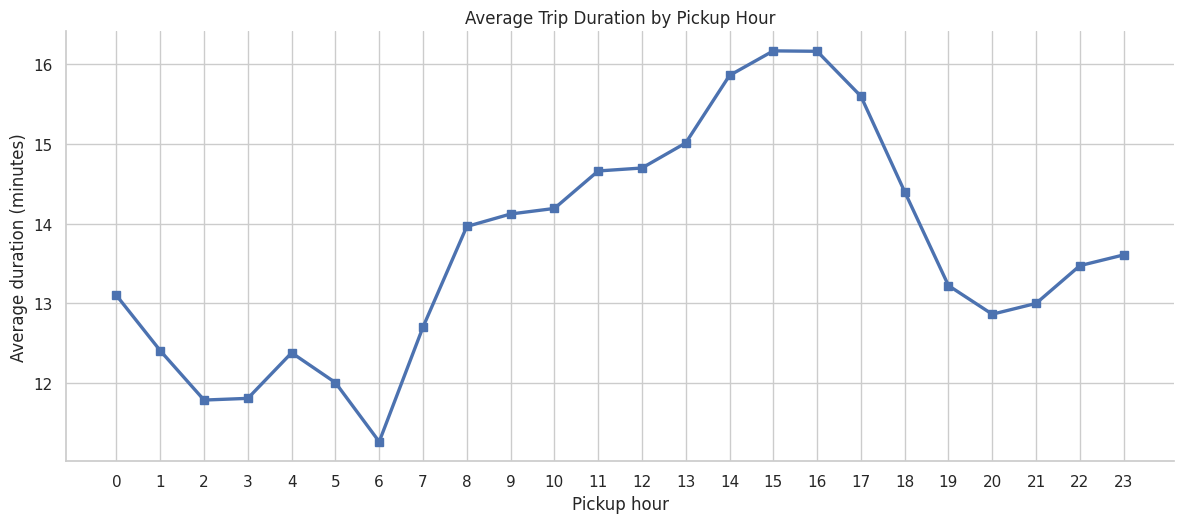

In [ ]:
# how travel time rises before the evening demand peak
fig, ax = plt.subplots(figsize=(12, 5.4))
ax.plot(hourly_duration["hour"], hourly_duration["avg_duration_min"], marker="s", linewidth=2.4)
ax.set(title="Average Trip Duration by Pickup Hour", xlabel="Pickup hour", ylabel="Average duration (minutes)")
ax.set_xticks(range(24))
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(visuals_dir / "04_avg_duration_by_hour.png", dpi=220, bbox_inches="tight")
plt.show()

## Monthly demand trend

In [ ]:
# trips by month and also normalize by number of observed calendar days
monthly_summary = (
    analysis_df.groupby(["month_num", "month"])
    .agg(trips=("id", "size"), avg_duration_min=("trip_duration_min", "mean"), observed_days=("date", "nunique"))
    .reset_index()
    .sort_values("month_num")
)
monthly_summary["avg_trips_per_day"] = monthly_summary["trips"] / monthly_summary["observed_days"]

display(monthly_summary.round(2))

,month_num,month,trips,avg_duration_min,observed_days,avg_trips_per_day
0,1,Jan,228064,13.24,31,7356.90
1,2,Feb,236609,13.23,29,8158.93
2,3,Mar,254306,13.69,31,8203.42
3,4,Apr,249713,14.20,30,8323.77
4,5,May,246579,14.79,31,7954.16
5,6,Jun,232525,14.91,30,7750.83


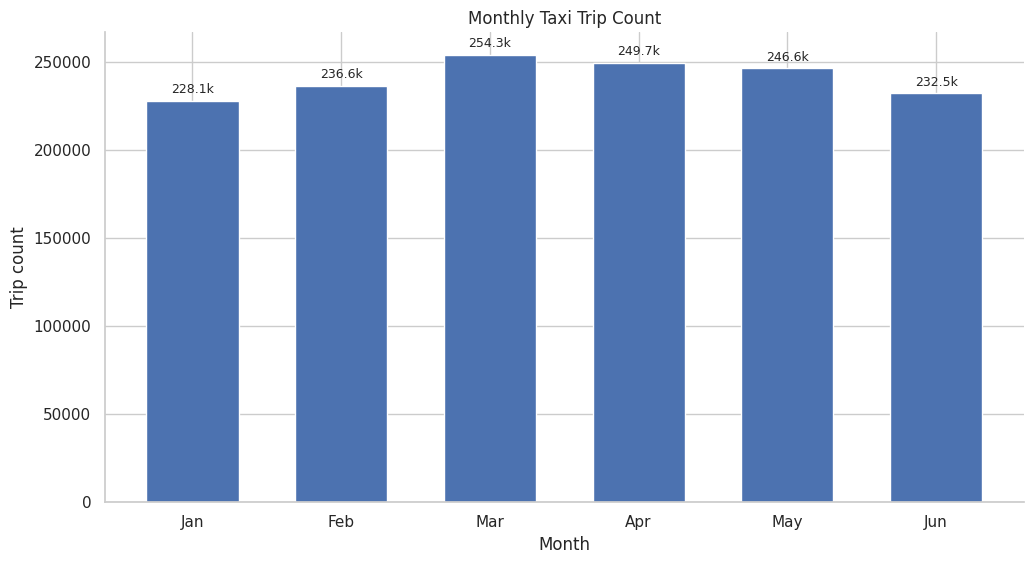

In [ ]:
# keeping the required chart focused on monthly trip counts
fig, ax = plt.subplots(figsize=(10.5, 5.8))
bars = ax.bar(monthly_summary["month"], monthly_summary["trips"], width=0.62)
for bar, value in zip(bars, monthly_summary["trips"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 2500, f"{value/1000:.1f}k", ha="center", va="bottom", fontsize=9)
ax.set(title="Monthly Taxi Trip Count", xlabel="Month", ylabel="Trip count")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(visuals_dir / "05_monthly_trip_count.png", dpi=220, bbox_inches="tight")
plt.show()

The file covers **January through June only**, so the chart describes a six-month pattern rather than full-year seasonality. March has the largest raw trip count, while April has the highest trips-per-observed-day rate. Weather is not present in the dataset, so weather-based causal explanations should not be asserted from this analysis alone.

## ADDITION — Hour × weekday demand heatmap

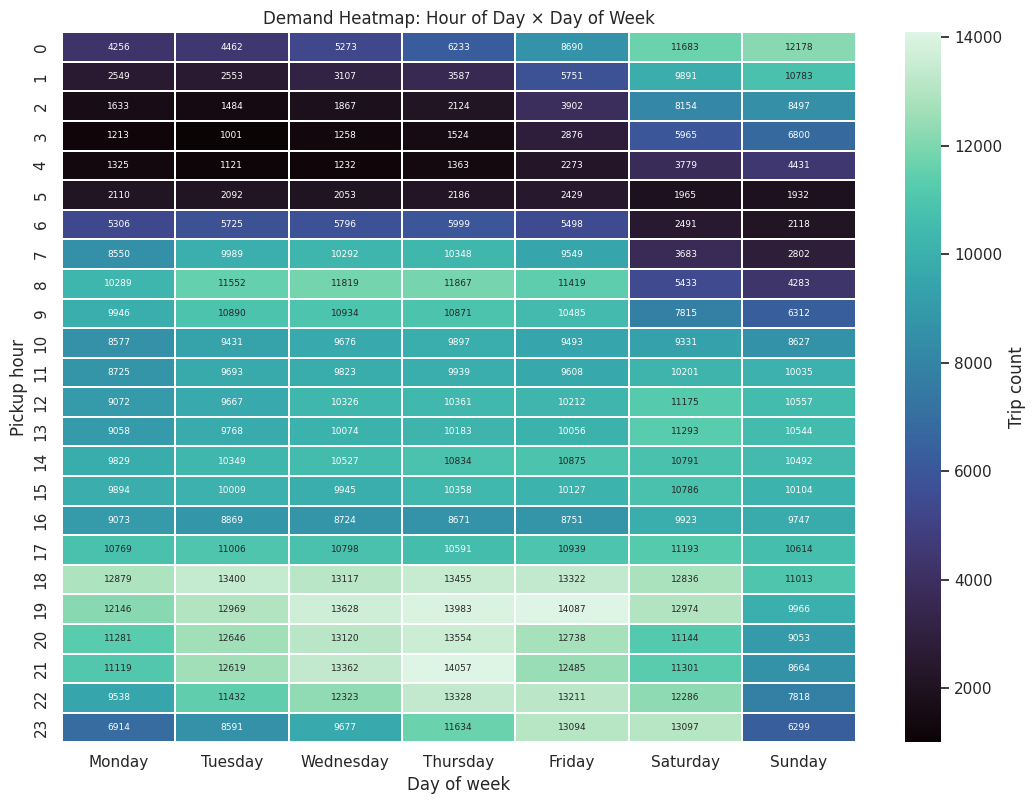

busiest hour-day cell: Friday at 19:00 | 14,087 trips


In [ ]:
# a complete hour-by-weekday demand matrix
heatmap_data = analysis_df.pivot_table(
    index="hour", columns="weekday", values="id", aggfunc="count", observed=True
).fillna(0)

fig, ax = plt.subplots(figsize=(10.8, 8.2))
sns.heatmap(
    heatmap_data, cmap="mako", annot=True, fmt=".0f",
    annot_kws={"fontsize": 6.5}, linewidths=0.15,
    cbar_kws={"label": "Trip count"}, ax=ax
)
ax.set(title="Demand Heatmap: Hour of Day × Day of Week", xlabel="Day of week", ylabel="Pickup hour")
fig.tight_layout()
fig.savefig(visuals_dir / "06_hour_weekday_heatmap.png", dpi=220, bbox_inches="tight")
plt.show()

max_position = np.unravel_index(np.argmax(heatmap_data.to_numpy()), heatmap_data.shape)
print(
    f"busiest hour-day cell: {heatmap_data.columns[max_position[1]]} "
    f"at {heatmap_data.index[max_position[0]]:02d}:00 | "
    f"{int(heatmap_data.to_numpy()[max_position]):,} trips"
)

## Vendor duration comparison

In [ ]:
# vendor_id identifies providers, not individual drivers
vendor_summary = (
    analysis_df.groupby("vendor_id")
    .agg(
        trips=("id", "size"),
        avg_duration_min=("trip_duration_min", "mean"),
        median_duration_min=("trip_duration_min", "median")
    )
    .reset_index()
)
vendor_summary["trip_share_pct"] = vendor_summary["trips"] / len(analysis_df) * 100

display(vendor_summary.round(2))

,vendor_id,trips,avg_duration_min,median_duration_min,trip_share_pct
0,1,673164,13.93,11.05,46.5
1,2,774632,14.08,11.12,53.5


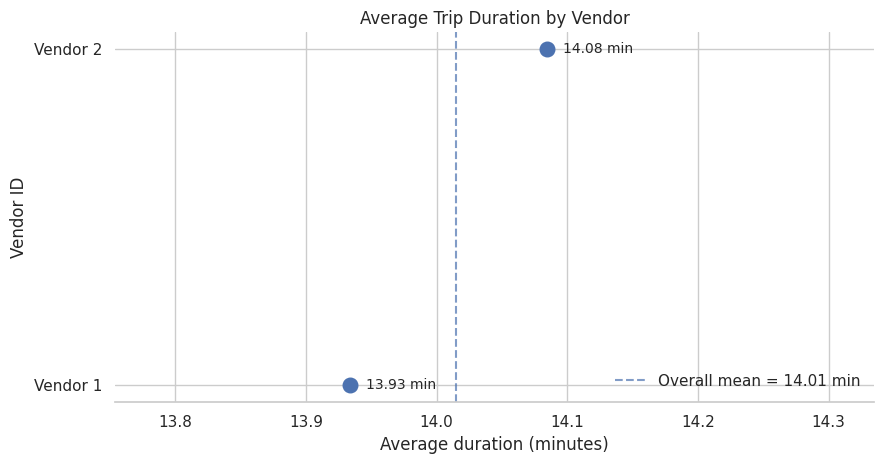

In [ ]:
# a dot comparison so a small vendor difference is visible without a misleading truncated bar axis
overall_avg_duration = analysis_df["trip_duration_min"].mean()

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.scatter(vendor_summary["avg_duration_min"], vendor_summary["vendor_id"], s=110, zorder=3)
ax.axvline(overall_avg_duration, linestyle="--", linewidth=1.5, alpha=0.7, label=f"Overall mean = {overall_avg_duration:.2f} min")

for _, row in vendor_summary.iterrows():
    ax.text(row["avg_duration_min"] + 0.012, row["vendor_id"], f"{row['avg_duration_min']:.2f} min", va="center", fontsize=10)

ax.set(
    title="Average Trip Duration by Vendor",
    xlabel="Average duration (minutes)",
    ylabel="Vendor ID"
)
ax.set_yticks(vendor_summary["vendor_id"])
ax.set_yticklabels([f"Vendor {vendor}" for vendor in vendor_summary["vendor_id"]])
ax.set_xlim(vendor_summary["avg_duration_min"].min() - 0.18, vendor_summary["avg_duration_min"].max() + 0.25)
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right", "left"]].set_visible(False)
fig.tight_layout()
fig.savefig(visuals_dir / "07_vendor_duration_comparison.png", dpi=220, bbox_inches="tight")
plt.show()


## Operational KPI summary

A compact KPI layer translates the exploratory results into fleet-planning metrics that can be monitored directly.


In [ ]:
# summarizing decision-oriented metrics from the validated aggregations
peak_to_offpeak_ratio = peak_row["trips"] / offpeak_row["trips"]
weekday_daily = day_type_summary.loc["Weekday", "mean"]
weekend_daily = day_type_summary.loc["Weekend", "mean"]
weekday_weekend_delta_pct = (weekday_daily / weekend_daily - 1) * 100
removed_share_pct = (~valid_duration).mean() * 100
mean_duration_change_pct = (analysis_df["trip_duration_min"].mean() / df["trip_duration_min"].mean() - 1) * 100
evening_rush_share_pct = analysis_df["hour"].isin([17, 18, 19]).mean() * 100

operational_kpis = pd.DataFrame({
    "kpi": [
        "peak-to-off-peak demand ratio",
        "weekday vs weekend daily demand delta (%)",
        "rows removed by duration filter (%)",
        "mean duration change after filtering (%)",
        "share of trips from 17:00–20:00 (%)"
    ],
    "value": [
        peak_to_offpeak_ratio,
        weekday_weekend_delta_pct,
        removed_share_pct,
        mean_duration_change_pct,
        evening_rush_share_pct
    ]
})

display(operational_kpis.round(2))


,kpi,value
0,peak-to-off-peak demand ratio,6.10
1,weekday vs weekend daily demand delta (%),0.27
2,rows removed by duration filter (%),0.74
3,mean duration change after filtering (%),-12.36
4,share of trips from 17:00–20:00 (%),17.66


## Operational insights for fleet management

1. **Stage more vehicles for the evening surge.** Demand reaches its maximum at 18:00–19:00 and remains elevated through the following evening hours, so shift overlap and vehicle availability should be strongest before that window begins.

2. **Use the 05:00 trough for low-disruption operations.** The lowest hourly demand occurs at 05:00, making the early-morning period better suited to refueling, charging, cleaning, routine inspections, or planned driver breaks.

3. **Plan staffing with both day-of-week and hour-of-day effects.** Friday has the highest total demand, and the heatmap shows that Friday evening is the single busiest hour-day combination. A flat weekly roster would therefore miss a concentrated capacity requirement.

4. **Separate trip volume from expected service time.** Average duration is highest in the mid-afternoon, before hourly trip volume reaches its evening maximum. Fleet managers should account for vehicles being occupied longer during those hours rather than allocating vehicles from demand count alone.

## Improvement layer — normalized metrics and reusable outputs

In [ ]:
# exported compact tables so the findings can be reused outside the notebook
hourly_summary.to_csv(outputs_dir / "hourly_summary.csv", index=False)
weekday_summary.to_csv(outputs_dir / "weekday_summary.csv", index=False)
monthly_summary.to_csv(outputs_dir / "monthly_summary.csv", index=False)
vendor_summary.to_csv(outputs_dir / "vendor_summary.csv", index=False)
day_type_summary.to_csv(outputs_dir / "weekday_vs_weekend_daily_summary.csv")
operational_kpis.to_csv(outputs_dir / "operational_kpi_summary.csv", index=False)

print("summary tables exported to outputs/")

summary tables exported to outputs/


Two additions improve interpretation beyond the minimum requirements. First, weekday vs weekend demand is normalized at the calendar-day level rather than compared only by total trips. Second, monthly demand includes trips per observed day, preventing month length from being mistaken for stronger demand.
A dedicated operational KPI table also quantifies the peak/off-peak gap, weekday–weekend daily difference, filtering impact, and evening-rush concentration so the analysis ends with measurable decision metrics rather than only descriptive charts.


## Double validation

In [ ]:
# run two validation layers: data integrity first, then aggregation and file reconciliation
required_columns = {"id", "vendor_id", "pickup_datetime", "trip_duration"}
visual_files = [
    "01_hourly_demand.png",
    "02_weekday_demand.png",
    "03_trip_duration_distribution.png",
    "04_avg_duration_by_hour.png",
    "05_monthly_trip_count.png",
    "06_hour_weekday_heatmap.png",
    "07_vendor_duration_comparison.png",
]
output_files = [
    "hourly_summary.csv",
    "weekday_summary.csv",
    "monthly_summary.csv",
    "vendor_summary.csv",
    "weekday_vs_weekend_daily_summary.csv",
    "operational_kpi_summary.csv",
]

layer_1 = {
    "source shape matches dataset": source_shape == (1_458_644, 11),
    "required source columns present": required_columns.issubset(df.columns),
    "pickup_datetime parsed": pd.api.types.is_datetime64_any_dtype(df["pickup_datetime"]),
    "parsed pickup times are complete": df["pickup_datetime"].notna().all(),
    "duration conversion is exact": np.allclose(analysis_df["trip_duration_min"] * 60, analysis_df["trip_duration"]),
    "all cleaned trips are 1–120 min": analysis_df["trip_duration_min"].between(1, 120).all(),
    "removed rows reconcile with filter": len(df) - len(analysis_df) == ((df["trip_duration_min"] < 1) | (df["trip_duration_min"] > 120)).sum(),
    "hour extraction is valid": analysis_df["hour"].between(0, 23).all(),
    "weekday extraction is complete": analysis_df["weekday"].notna().all(),
    "month extraction is complete": analysis_df["month"].notna().all(),
}

layer_2 = {
    "24 hourly groups present": hourly_summary["hour"].nunique() == 24,
    "7 weekday groups present": weekday_summary["weekday"].nunique() == 7,
    "6 observed months present": set(monthly_summary["month_num"]) == set(range(1, 7)),
    "hourly totals reconcile": int(hourly_summary["trips"].sum()) == len(analysis_df),
    "weekday totals reconcile": int(weekday_summary["trips"].sum()) == len(analysis_df),
    "monthly totals reconcile": int(monthly_summary["trips"].sum()) == len(analysis_df),
    "vendor totals reconcile": int(vendor_summary["trips"].sum()) == len(analysis_df),
    "heatmap is 24 × 7": heatmap_data.shape == (24, 7),
    "heatmap totals reconcile": int(heatmap_data.to_numpy().sum()) == len(analysis_df),
    "hourly duration has no gaps": hourly_duration["avg_duration_min"].notna().all(),
    "all seven visuals exported": all((visuals_dir / name).is_file() and (visuals_dir / name).stat().st_size > 0 for name in visual_files),
    "all six summary tables exported": all((outputs_dir / name).is_file() and (outputs_dir / name).stat().st_size > 0 for name in output_files),
}

validation = pd.DataFrame(
    [("layer 1 — data integrity", check, passed) for check, passed in layer_1.items()]
    + [("layer 2 — reconciliation", check, passed) for check, passed in layer_2.items()],
    columns=["validation_layer", "check", "passed"]
)

display(validation)
assert validation["passed"].all(), "one or more validation checks failed"
print(f"double validation passed: {len(layer_1)} data checks + {len(layer_2)} reconciliation checks")


,validation_layer,check,passed
0,layer 1 — data integrity,source shape matches dataset,True
1,layer 1 — data integrity,required source columns present,True
2,layer 1 — data integrity,pickup_datetime parsed,True
3,layer 1 — data integrity,parsed pickup times are complete,True
4,layer 1 — data integrity,duration conversion is exact,True
5,layer 1 — data integrity,all cleaned trips are 1–120 min,True
6,layer 1 — data integrity,removed rows reconcile with filter,True
7,layer 1 — data integrity,hour extraction is valid,True
8,layer 1 — data integrity,weekday extraction is complete,True
9,layer 1 — data integrity,month extraction is complete,True


double validation passed: 10 data checks + 12 reconciliation checks


### Final note

The cleaned results should be treated as the source of truth for this submission. In particular, the raw mean is inflated by extreme durations; after the required filter, the mean is about 14 minutes and the median is about 11 minutes. The data also shows only a handful of trips above 24 hours, so any larger quoted count should be rechecked against a different filtering rule or dataset version.